In [1]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.quadratic import _vote_quadratic

In [2]:
NUM_VOTERS = 100
NUM_CANDIDATES = 5
NUM_PREFERENCES = 2
NUM_SIMULATIONS = 50  # the node trajectories

In [3]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

In [4]:
env.initialize_network()

In [5]:
env.candidates

[Candidate(id=99, policy={'mean': Array([1.1237826, 1.3766265], dtype=float32), 'precision': Array([0.6409994 , 0.85308594], dtype=float32)}, vote_count=0),
 Candidate(id=100, policy={'mean': Array([0.82422304, 0.4968078 ], dtype=float32), 'precision': Array([0.502776 , 0.6611074], dtype=float32)}, vote_count=0),
 Candidate(id=101, policy={'mean': Array([1.7034531 , 0.11171865], dtype=float32), 'precision': Array([0.41243482, 0.946472  ], dtype=float32)}, vote_count=0),
 Candidate(id=102, policy={'mean': Array([1.779484 , 1.4311776], dtype=float32), 'precision': Array([0.5920388, 0.7900999], dtype=float32)}, vote_count=0),
 Candidate(id=103, policy={'mean': Array([0.6493707, 1.9912264], dtype=float32), 'precision': Array([0.89359564, 0.9998488 ], dtype=float32)}, vote_count=0)]

In [6]:
# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
## run n simulations
sim = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

In [7]:
sim

{0: {'vote_round_1': Array([103, 100,  99, 101, 103, 102, 101, 100, 103,  99, 100, 102, 101,
         102,  99, 102, 103, 101, 103,  99, 102, 101, 101,  99,  99, 103,
         101, 100, 100, 100,  99, 100,  99, 102,  99, 102, 101,  99, 102,
         102, 101,  99, 102, 100, 103, 103, 100, 103, 102, 100, 102, 101,
         102, 103,  99, 101, 101, 103, 100, 102, 102, 100,  99, 103, 102,
          99, 102,  99, 100, 100, 102, 100, 103, 100,  99, 103,  99,  99,
         101, 101, 100, 103, 102, 100, 102, 102, 103,  99, 101, 103,  99,
         101, 100,  99, 102, 103, 100, 102, 100, 100], dtype=int32),
  'softmax_probs_round_1': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [8]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_99817/1607318703.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


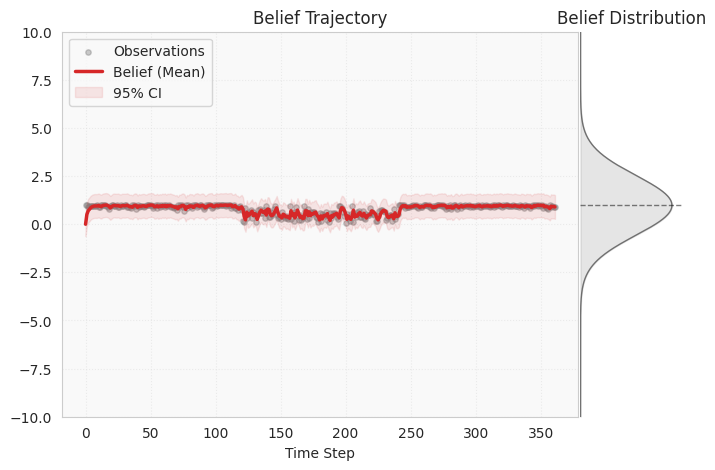

In [9]:
traj_data = adapter.get_voter_trajectory_data(env, voter_id=11)
fig, ax1, ax2 = viz.plot_belief_trajectory(
    **traj_data,
    ylim=(-10, 10),
)
ax1.set_title("Belief Trajectory")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
ax2.set_title("Belief Distribution")
fig.set_size_inches(8, 5)
plt.show()

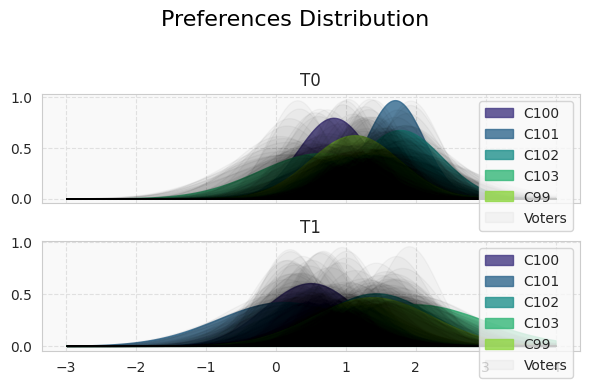

In [10]:
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)
fig.suptitle("Preferences Distribution", fontsize=16)
fig.set_size_inches(6, 4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

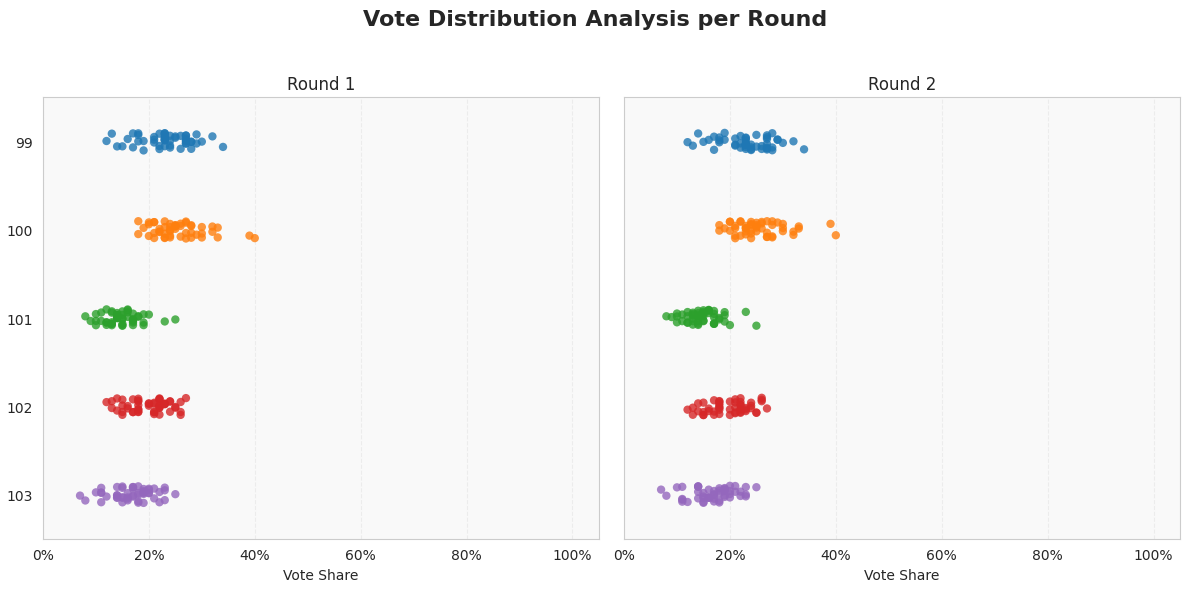

In [11]:
votes_data = adapter.extract_vote_counts(env.df)
fig, axes = viz.plot_vote_proportions(votes_data, plot_kind="stripplot")
plt.show()